In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

## import tensorflow

In [10]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


## Download nltk stopwords

In [12]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Sakib
[nltk_data]     Malik\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## Load dataset

In [13]:
df=pd.read_csv('spam_ham_dataset.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [14]:
df.size

20684

In [15]:
df.isnull().sum()

Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(5171, 4)

## Check data is balance or not

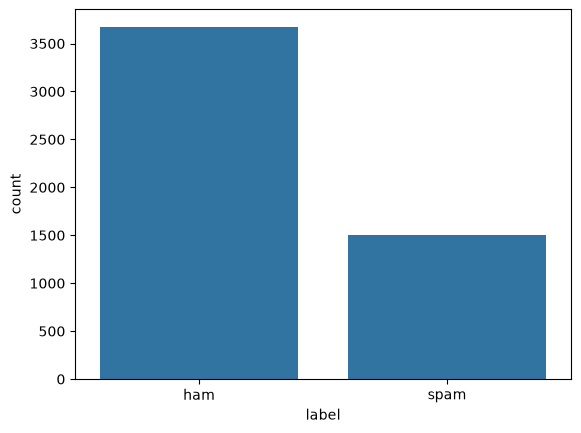

In [19]:
sns.countplot(x='label',data=df)
plt.show()

## Balance the dataset add some more in spam

HAM SHAPE (3672, 4)
SPAM SHAPE (1499, 4)
HASM SHAPE (1499, 4)
HASM SHAPE (2998, 4)


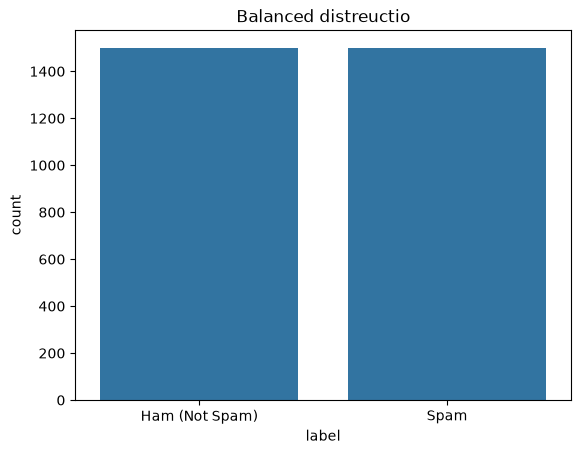

In [27]:
ham_msg=df[df['label']=='ham']
spam_msg=df[df['label']=='spam']
print("HAM SHAPE",ham_msg.shape)
print("SPAM SHAPE",spam_msg.shape)

ham_msg_balanced=ham_msg.sample(n=len(spam_msg),random_state=42)
print("HASM SHAPE",ham_msg_balanced.shape)
balanced_dataset=pd.concat([ham_msg_balanced,spam_msg]).reset_index(drop=True)
print("HASM SHAPE",balanced_dataset.shape)

sns.countplot(x='label',data=balanced_dataset)
plt.title("Balanced distreuctio")
plt.xticks(ticks=[0, 1], labels=['Ham (Not Spam)', 'Spam'])
plt.show()


## Clean the text

In [30]:
balanced_dataset['text']=balanced_dataset['text'].str.replace('Subject','')
balanced_dataset.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


## Remove all puncuations

In [39]:
punctuations_list=string.punctuation

def remove_punctuation(text):
    temp=str.maketrans('','',punctuations_list)
    return text.translate(temp)


balanced_dataset['text']=balanced_dataset['text'].apply(lambda x: remove_punctuation(x))
balanced_dataset.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


## Remove stopwords

In [42]:
def remove_stopwords(text):
    stop_words=stopwords.words('english')
    imp_words=[]
    for word in str(text).split():
        word =word.lower()
        if word not in stop_words:
            imp_words.append(word)
    output=" ".join(imp_words)
    return output


balanced_dataset['text']=balanced_dataset['text'].map(remove_stopwords)
balanced_dataset.head() 

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


## Visulation word count - 
##### it means which word in comes more time will bigger otherwise small

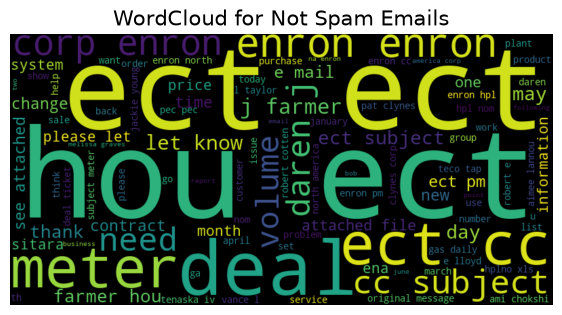

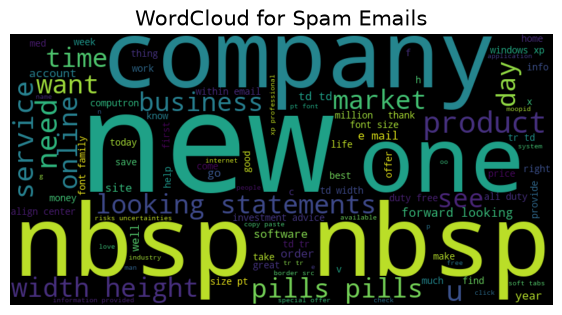

In [44]:
def plot_word_cloud(data,typ):
    email_corpus=" ".join(data['text'])
    wc=WordCloud(background_color="black",max_words=100,width=800,height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_dataset[balanced_dataset['label']=='ham'],typ="Not Spam")
plot_word_cloud(balanced_dataset[balanced_dataset['label']=='spam'],typ="Spam")

## Tokenization and padding

In [47]:
X=balanced_dataset['text']
y=balanced_dataset['label']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=42,test_size=0.2
)

tokenizer=Tokenizer()
tokenizer.fit_on_texts(X_train)

train_sequence=tokenizer.texts_to_sequences(X_train)
test_sequence=tokenizer.texts_to_sequences(y_test)

max_len=100

train_sequence=pad_sequences(train_sequence,maxlen=max_len,padding='post',truncating="post")
test_sequence=pad_sequences(test_sequence,maxlen=max_len,padding='post',truncating="post")

y_train=(y_train=='spam').astype(int)
y_test=(y_test=='spam').astype(int)

## Define the model

In [59]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 32)        │     1,274,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,278,625 (4.88 MB)

 Trainable params: 1,278,625 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

## Train model

In [60]:
es=EarlyStopping(patience=3,monitor='val_accuracy',restore_best_weights=True)
lr=ReduceLROnPlateau(patience=2,monitor='val_loss',factor=0.5,verbose=False)


history=model.fit(
    train_sequence,y_train,
    validation_data=(test_sequence,y_test),
    epochs=20,
    batch_size=32,
    callbacks=[lr,es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.5746 - loss: 0.6717 - val_accuracy: 0.4750 - val_loss: 0.7666 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9466 - loss: 0.2031 - val_accuracy: 0.4750 - val_loss: 1.4908 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9566 - loss: 0.1727 - val_accuracy: 0.4750 - val_loss: 1.7412 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9633 - loss: 0.1549 - val_accuracy: 0.4750 - val_loss: 1.6212 - learning_rate: 5.0000e-04


## Evaluate Model

In [61]:
test_loss,test_accuracy=model.evaluate(test_sequence,y_test)
print("Test loss",test_loss)
print("Test Accuracy:",test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4750 - loss: 0.7666
Test loss 0.7666443586349487
Test Accuracy: 0.4749999940395355


## Check history

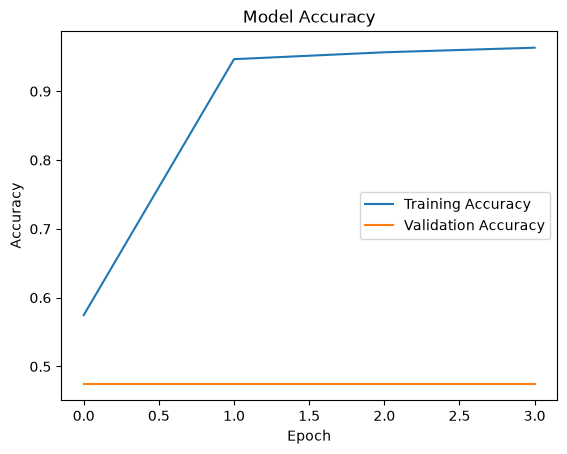

In [62]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()